In [ ]:
 # https://keras.io/examples/rl/ddpg_pendulum/

In [ ]:
import gym
import tensorflow as tf
import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pickle

In [ ]:
import gym
from gym import spaces
from gym.utils import seeding
import numpy as np
from os import path

class custom_PendulumEnv(gym.Env):
    metadata = {
        'render.modes' : ['human', 'rgb_array'],
        'video.frames_per_second' : 30
    }

    def __init__(self):
        self.max_speed=8
        self.max_torque=2.
        self.dt=.05
        self.viewer = None
        self.max_step = 200
        self.current_step = 0

        high = np.array([1., 1., self.max_speed])
        self.action_space = spaces.Box(low=-self.max_torque, high=self.max_torque, shape=(1,))
        self.observation_space = spaces.Box(low=-high, high=high)

        self.seed()

        ### Customization changes ############################
        '''add ElectricalDCMotorEnv to the CartPole class
        and assign values to
        Resistor_R, inductor_L, torque_const_Kt and bemf_const_Ke'''

        self.tau1 = .05  # seconds between state updates
        self.DCMotorModel = ElectricalDCMotorEnv()
        self.DCMotorModel.tau1 = self.tau1
        self.DCMotorModel.Resistor_R = 1.0
        self.DCMotorModel.inductor_L = 0.1
        self.DCMotorModel.torque_const_Kt = 1.0
        self.DCMotorModel.bemf_const_Ke = 1.0
        ####


    def seed(self, seed=None):
        self.np_random, seed = seeding.np_random(seed)
        return [seed]

    def step(self,u):
        th, thdot = self.state # th := theta

        g = 10.
        m = 1.
        l = 1.
        dt = self.dt

        u = np.clip(u, -self.max_torque, self.max_torque)[0] #numpy.clip() function is used to Clip (limit) the values in an array
        current_ref = u/self.DCMotorModel.torque_const_Kt
        u_after_pid = self.DCMotorModel.step(current_ref = current_ref, theta_dot = thdot)
        #u_after_pid=u #change for perfect appying torque
        u_after_pid = [u_after_pid]
        u_after_pid = np.clip(u_after_pid, -self.max_torque, self.max_torque)[0]

        self.last_u = u_after_pid
        costs = angle_normalize(th)**2 + .1*thdot**2 + .001*(u_after_pid**2)


        newthdot = thdot + (-3*g/(2*l) * np.sin(th + np.pi) + 3./(m*l**2)*u_after_pid) * dt
        newth = th + newthdot*dt
        newthdot = np.clip(newthdot, -self.max_speed, self.max_speed) #pylint: disable=E1111 #numpy.clip() function is used to Clip (limit) the values in an array

        self.state = np.array([newth, newthdot])

        self.current_step += 1
        done = bool(self.current_step % self.max_step == 0)

        return self._get_obs(), -costs, done, {} , u , u_after_pid

    def reset(self):
        high = np.array([np.pi, 1])
        self.state = self.np_random.uniform(low=-high, high=high)
        self.last_u = None
        self.current_step = 0

        self.DCMotorModel.current = 0.0
        self.DCMotorModel.current_error = 0.0
        self.DCMotorModel.current_error_acc = 0.0
        self.DCMotorModel.current_error_prev = 0.0
        ###
        self.DCMotorModel.voltage_input = 0.0
        self.DCMotorModel.thetadot = self.state[1]+np.random.randn()*1e-4

        return self._get_obs()

    def _get_obs(self):
        theta, thetadot = self.state
        return np.array([np.cos(theta), np.sin(theta), thetadot])

    def render(self, mode='human'):

        if self.viewer is None:
            from gym.envs.classic_control import rendering
            self.viewer = rendering.Viewer(500,500)
            self.viewer.set_bounds(-2.2,2.2,-2.2,2.2)
            rod = rendering.make_capsule(1, .2)
            rod.set_color(.8, .3, .3)
            self.pole_transform = rendering.Transform()
            rod.add_attr(self.pole_transform)
            self.viewer.add_geom(rod)
            axle = rendering.make_circle(.05)
            axle.set_color(0,0,0)
            self.viewer.add_geom(axle)
            fname = path.join(path.dirname(__file__), "assets/clockwise.png")
            self.img = rendering.Image(fname, 1., 1.)
            self.imgtrans = rendering.Transform()
            self.img.add_attr(self.imgtrans)

        self.viewer.add_onetime(self.img)
        self.pole_transform.set_rotation(self.state[0] + np.pi/2)
        if self.last_u:
            self.imgtrans.scale = (-self.last_u/2, np.abs(self.last_u)/2)

        return self.viewer.render(return_rgb_array = mode=='rgb_array')

    def close(self):
        if self.viewer: self.viewer.close()

def angle_normalize(x):
    return (((x+np.pi) % (2*np.pi)) - np.pi)

In [ ]:
class ElectricalDCMotorEnv():

      def __init__(self):
        self.Resistor_R = 1.0
        self.inductor_L = 0.1
        self.torque_const_Kt = 1.0
        self.bemf_const_Ke = 1.0
        self.tau1 = 0.05
        #
        self.Kp = 1.0
        self.Ki = 20.0
        self.Kd = 10**(-6)
        self.aL=10.0**(-3) #Low pass parameter
        self.aH = 10.0**2 #High pass parameter

        #
        self.current = 0.0
        self.current_error = 0.0
        self.current_error_acc = 0.0
        self.current_error_prev = 0.0
        self.voltage_input = 0.0
        self.thetadot = 0.0
        self.PID_Discretization = "Simple" #"Backward""Simple", " "Bilinear" , "Forward" "Simple"

      def step(self, current_ref, theta_dot):
        aL = self.aL
        aH = self.aH
        self.current_error = current_ref-self.current
        delta_error = self.current_error-self.current_error_prev

        if self.PID_Discretization == "Simple":
          self.current_error_acc += self.current_error*self.tau1
          HP_delta_error = delta_error

        elif self.PID_Discretization == "Backward":
          self.current_error_acc = (self.current_error_acc+(self.current_error)*self.tau1)/(1+aL*self.tau1)
          HP_delta_error = (self.current_error + aH*delta_error)/(1+aL*self.tau1)#High Pass

        elif self.PID_Discretization == "Bilinear":
          error_avg = (self.current_error+self.current_error_prev)/2
          self.current_error_acc =  ((1-aL*self.tau1/2)*self.current_error_acc + error_avg*self.tau1)/(1+aL*self.tau1/2)#Low Pass
          HP_delta_error =  ((1-aL*self.tau1/2)*self.current_error + aH*delta_error)/(1+aL*self.tau1/2)#High Pass

        else:
          self.current_error_acc = (1-aL*self.tau1)*self.current_error_acc+(self.current_error_prev)*self.tau1 #Low Pass
          HP_delta_error = (1-aH*self.tau1)*self.current_error + aH*delta_error #High Pass

        P = self.Kp*self.current_error
        I = self.Ki*self.current_error_acc
        D = self.Kd*HP_delta_error/self.tau1
        voltage_BEMF = theta_dot*self.bemf_const_Ke
        #voltage_input = P+I+D+1*voltage_BEMF
        voltage_input = self.voltage_input +self.Ki*self.tau1*self.current_error +self.Kp*HP_delta_error +self.bemf_const_Ke*(theta_dot-self.thetadot)
        voltage_input = np.clip(voltage_input, -10, 10)
        #v=(voltage_input+self.voltage_input)/2

        self.current_error_prev = 0+self.current_error
        self.current += self.tau1*(voltage_input-voltage_BEMF-self.current*self.Resistor_R)/self.inductor_L

        self.voltage_input = voltage_input
        self.thetadot = theta_dot
        F = self.torque_const_Kt*self.current

        return F # return applied Tourqe

In [ ]:
env = custom_PendulumEnv()
env.DCMotorModel.PID_Discretization ="Simple" # "Forward" or "Backward" or" "Bilinear" or "Simple"

/usr/local/lib/python3.12/dist-packages/gym/spaces/box.py:128: UserWarning: WARN: Box bound precision lowered by casting to float32
  logger.warn(f"Box bound precision lowered by casting to {self.dtype}")


In [ ]:
'''
problem = "Pendulum-v1"
env = gym.make(problem)
'''


num_states = env.observation_space.shape[0]
print("Size of State Space ->  {}".format(num_states))
num_actions = env.action_space.shape[0]
print("Size of Action Space ->  {}".format(num_actions))

upper_bound = env.action_space.high[0]
lower_bound = env.action_space.low[0]

print("Max Value of Action ->  {}".format(upper_bound))
print("Min Value of Action ->  {}".format(lower_bound))

Size of State Space ->  3
Size of Action Space ->  1
Max Value of Action ->  2.0
Min Value of Action ->  -2.0


In [ ]:

class OUActionNoise:
    def __init__(self, mean, std_deviation, theta=0.15, dt=1e-2, x_initial=None):
        self.theta = theta
        self.mean = mean
        self.std_dev = std_deviation
        self.dt = dt
        self.x_initial = x_initial
        self.reset()

    def __call__(self):
        # Formula taken from https://www.wikipedia.org/wiki/Ornstein-Uhlenbeck_process.
        x = (
            self.x_prev
            + self.theta * (self.mean - self.x_prev) * self.dt
            + self.std_dev * np.sqrt(self.dt) * np.random.normal(size=self.mean.shape)
        )
        # Store x into x_prev
        # Makes next noise dependent on current one
        self.x_prev = x
        return x

    def reset(self):
        if self.x_initial is not None:
            self.x_prev = self.x_initial
        else:
            self.x_prev = np.zeros_like(self.mean)


In [ ]:
class Buffer:
    def __init__(self, buffer_capacity=100000, batch_size=64):
        # Number of "experiences" to store at max
        self.buffer_capacity = buffer_capacity
        # Num of tuples to train on.
        self.batch_size = batch_size

        # Its tells us num of times record() was called.
        self.buffer_counter = 0

        # Instead of list of tuples as the exp.replay concept go
        # We use different np.arrays for each tuple element
        self.state_buffer = np.zeros((self.buffer_capacity, num_states))
        self.action_buffer = np.zeros((self.buffer_capacity, num_actions))
        self.reward_buffer = np.zeros((self.buffer_capacity, 1))
        self.next_state_buffer = np.zeros((self.buffer_capacity, num_states))

    # Takes (s,a,r,s') observation tuple as input
    def record(self, obs_tuple):
        # Set index to zero if buffer_capacity is exceeded,
        # replacing old records
        index = self.buffer_counter % self.buffer_capacity

        self.state_buffer[index] = obs_tuple[0]
        self.action_buffer[index] = obs_tuple[1]
        self.reward_buffer[index] = obs_tuple[2]
        self.next_state_buffer[index] = obs_tuple[3]

        self.buffer_counter += 1

    # Eager execution is turned on by default in TensorFlow 2. Decorating with tf.function allows
    # TensorFlow to build a static graph out of the logic and computations in our function.
    # This provides a large speed up for blocks of code that contain many small TensorFlow operations such as this one.
    @tf.function
    def update(
        self,
        state_batch,
        action_batch,
        reward_batch,
        next_state_batch,
    ):
        # Training and updating Actor & Critic networks.
        # See Pseudo Code.
        with tf.GradientTape() as tape:
            target_actions = target_actor(next_state_batch, training=True)
            y = reward_batch + gamma * target_critic(
                [next_state_batch, target_actions], training=True
            )
            critic_value = critic_model([state_batch, action_batch], training=True)
            critic_loss = keras.ops.mean(keras.ops.square(y - critic_value))

        critic_grad = tape.gradient(critic_loss, critic_model.trainable_variables)
        critic_optimizer.apply_gradients(
            zip(critic_grad, critic_model.trainable_variables)
        )

        with tf.GradientTape() as tape:
            actions = actor_model(state_batch, training=True)
            critic_value = critic_model([state_batch, actions], training=True)
            # Used `-value` as we want to maximize the value given
            # by the critic for our actions
            actor_loss = -keras.ops.mean(critic_value)

        actor_grad = tape.gradient(actor_loss, actor_model.trainable_variables)
        actor_optimizer.apply_gradients(
            zip(actor_grad, actor_model.trainable_variables)
        )

    # We compute the loss and update parameters
    def learn(self):
        # Get sampling range
        record_range = min(self.buffer_counter, self.buffer_capacity)
        # Randomly sample indices
        batch_indices = np.random.choice(record_range, self.batch_size)

        # Convert to tensors
        state_batch = keras.ops.convert_to_tensor(self.state_buffer[batch_indices])
        action_batch = keras.ops.convert_to_tensor(self.action_buffer[batch_indices])
        reward_batch = keras.ops.convert_to_tensor(self.reward_buffer[batch_indices])
        reward_batch = keras.ops.cast(reward_batch, dtype="float32")
        next_state_batch = keras.ops.convert_to_tensor(
            self.next_state_buffer[batch_indices]
        )

        self.update(state_batch, action_batch, reward_batch, next_state_batch)


# This update target parameters slowly
# Based on rate `tau`, which is much less than one.
def update_target(target, original, tau):
    target_weights = target.get_weights()
    original_weights = original.get_weights()

    for i in range(len(target_weights)):
        target_weights[i] = original_weights[i] * tau + target_weights[i] * (1 - tau)

    target.set_weights(target_weights)

In [ ]:

def get_actor():
    # Initialize weights between -3e-3 and 3-e3
    last_init = tf.random_uniform_initializer(minval=-0.003, maxval=0.003)

    inputs = layers.Input(shape=(num_states,))
    out = layers.Dense(256, activation="relu")(inputs)
    out = layers.Dense(256, activation="relu")(out)
    outputs = layers.Dense(1, activation="tanh", kernel_initializer=last_init)(out)

    # Our upper bound is 2.0 for Pendulum.
    outputs = outputs * upper_bound
    model = tf.keras.Model(inputs, outputs)
    return model


def get_critic():
    # State as input
    #state_input = layers.Input(shape=(num_states))
    state_input = layers.Input(shape=(num_states,))
    state_out = layers.Dense(16, activation="relu")(state_input)
    state_out = layers.Dense(32, activation="relu")(state_out)

    # Action as input
    #action_input = layers.Input(shape=(num_actions))
    action_input = layers.Input(shape=(num_actions,))
    action_out = layers.Dense(32, activation="relu")(action_input)

    # Both are passed through seperate layer before concatenating
    concat = layers.Concatenate()([state_out, action_out])

    out = layers.Dense(256, activation="relu")(concat)
    out = layers.Dense(256, activation="relu")(out)
    outputs = layers.Dense(1)(out)

    # Outputs single value for give state-action
    model = tf.keras.Model([state_input, action_input], outputs)

    return model


In [ ]:

def policy(state, noise_object):
    #print("state",state)
    sampled_actions = tf.squeeze(actor_model(state))
    noise = noise_object()
    # Adding noise to action
    sampled_actions = sampled_actions.numpy() + noise

    # We make sure action is within bounds
    legal_action = np.clip(sampled_actions, lower_bound, upper_bound) #numpy.clip() function is used to Clip (limit) the values in an array

    return [np.squeeze(legal_action)]


In [ ]:
std_dev = 0.2
ou_noise = OUActionNoise(mean=np.zeros(1), std_deviation=float(std_dev) * np.ones(1))

actor_model = get_actor()
critic_model = get_critic()

target_actor = get_actor()
target_critic = get_critic()

# Making the weights equal initially
target_actor.set_weights(actor_model.get_weights())
target_critic.set_weights(critic_model.get_weights())

# Learning rate for actor-critic models
critic_lr = 0.002
actor_lr = 0.001

critic_optimizer = tf.keras.optimizers.Adam(critic_lr)
actor_optimizer = tf.keras.optimizers.Adam(actor_lr)

total_episodes = 200
# Discount factor for future rewards
gamma = 0.99
# Used to update target networks
tau = 0.005

buffer = Buffer(50000, 64)

In [ ]:
actor_model.summary(expand_nested=True, show_trainable=True)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)                ┃ Output Shape          ┃    Param # ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━┩
│ input_layer (InputLayer)    │ (None, 3)             │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense (Dense)               │ (None, 256)           │      1,024 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_1 (Dense)             │ (None, 256)           │     65,792 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_2 (Dense)             │ (None, 1)             │        257 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ multiply (Multiply)         │ (None, 1)             │          0 │   -   │
└─────────────────────────────┴───────────────────────┴────────────┴───────┘

 Total params: 67,073 (262.00 KB)

 Trainable params: 67,073 (262.00 KB)

 Non-trainable params: 0 (0.00 B)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


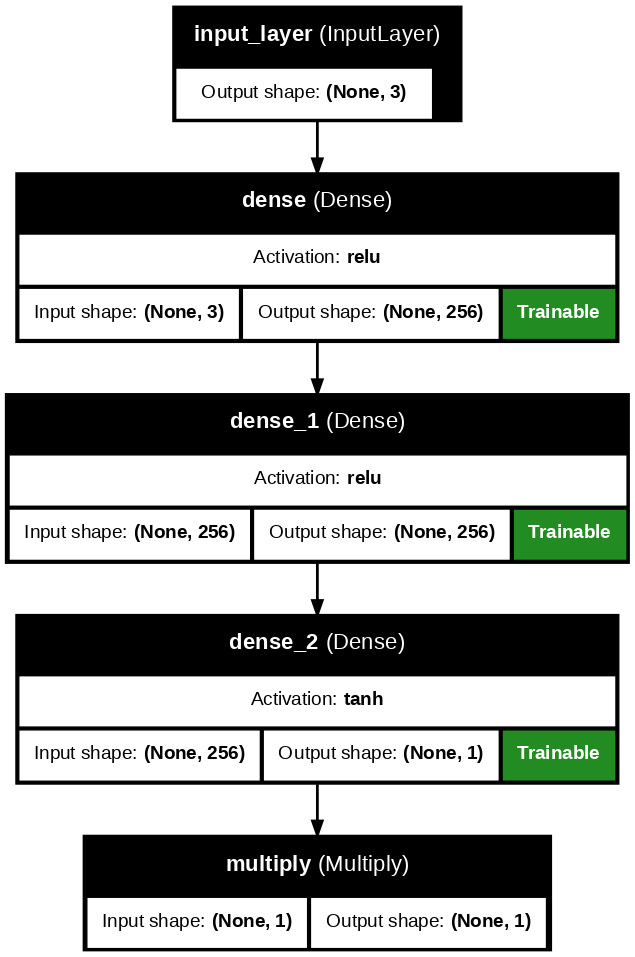

In [ ]:
keras.utils.plot_model(actor_model,show_shapes=True,show_layer_names=True, show_layer_activations=True,expand_nested=False, dpi=100, show_trainable=True)

In [ ]:
critic_model.summary(expand_nested=True, show_trainable=True)

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)      ┃ Output Shape    ┃   Param # ┃ Connected to   ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━┩
│ input_layer_1     │ (None, 3)       │         0 │ -              │   -   │
│ (InputLayer)      │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ dense_3 (Dense)   │ (None, 16)      │        64 │ input_layer_1… │   Y   │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ input_layer_2     │ (None, 1)       │         0 │ -              │   -   │
│ (InputLayer)      │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ dense_4 (Dense)   │ (None, 32)      │       544 │ dense_3[0][0]  │   Y   │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ dense_5 (Dense)   │ (None, 32)      │        64 │ input_layer_2… │   Y   │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ concatenate       │ (None, 64)      │         0 │ dense_4[0][0], │   -   │
│ (Concatenate)     │                 │           │ dense_5[0][0]  │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ dense_6 (Dense)   │ (None, 256)     │    16,640 │ concatenate[0… │   Y   │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ dense_7 (Dense)   │ (None, 256)     │    65,792 │ dense_6[0][0]  │   Y   │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ dense_8 (Dense)   │ (None, 1)       │       257 │ dense_7[0][0]  │   Y   │
└───────────────────┴─────────────────┴───────────┴────────────────┴───────┘

 Total params: 83,361 (325.63 KB)

 Trainable params: 83,361 (325.63 KB)

 Non-trainable params: 0 (0.00 B)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


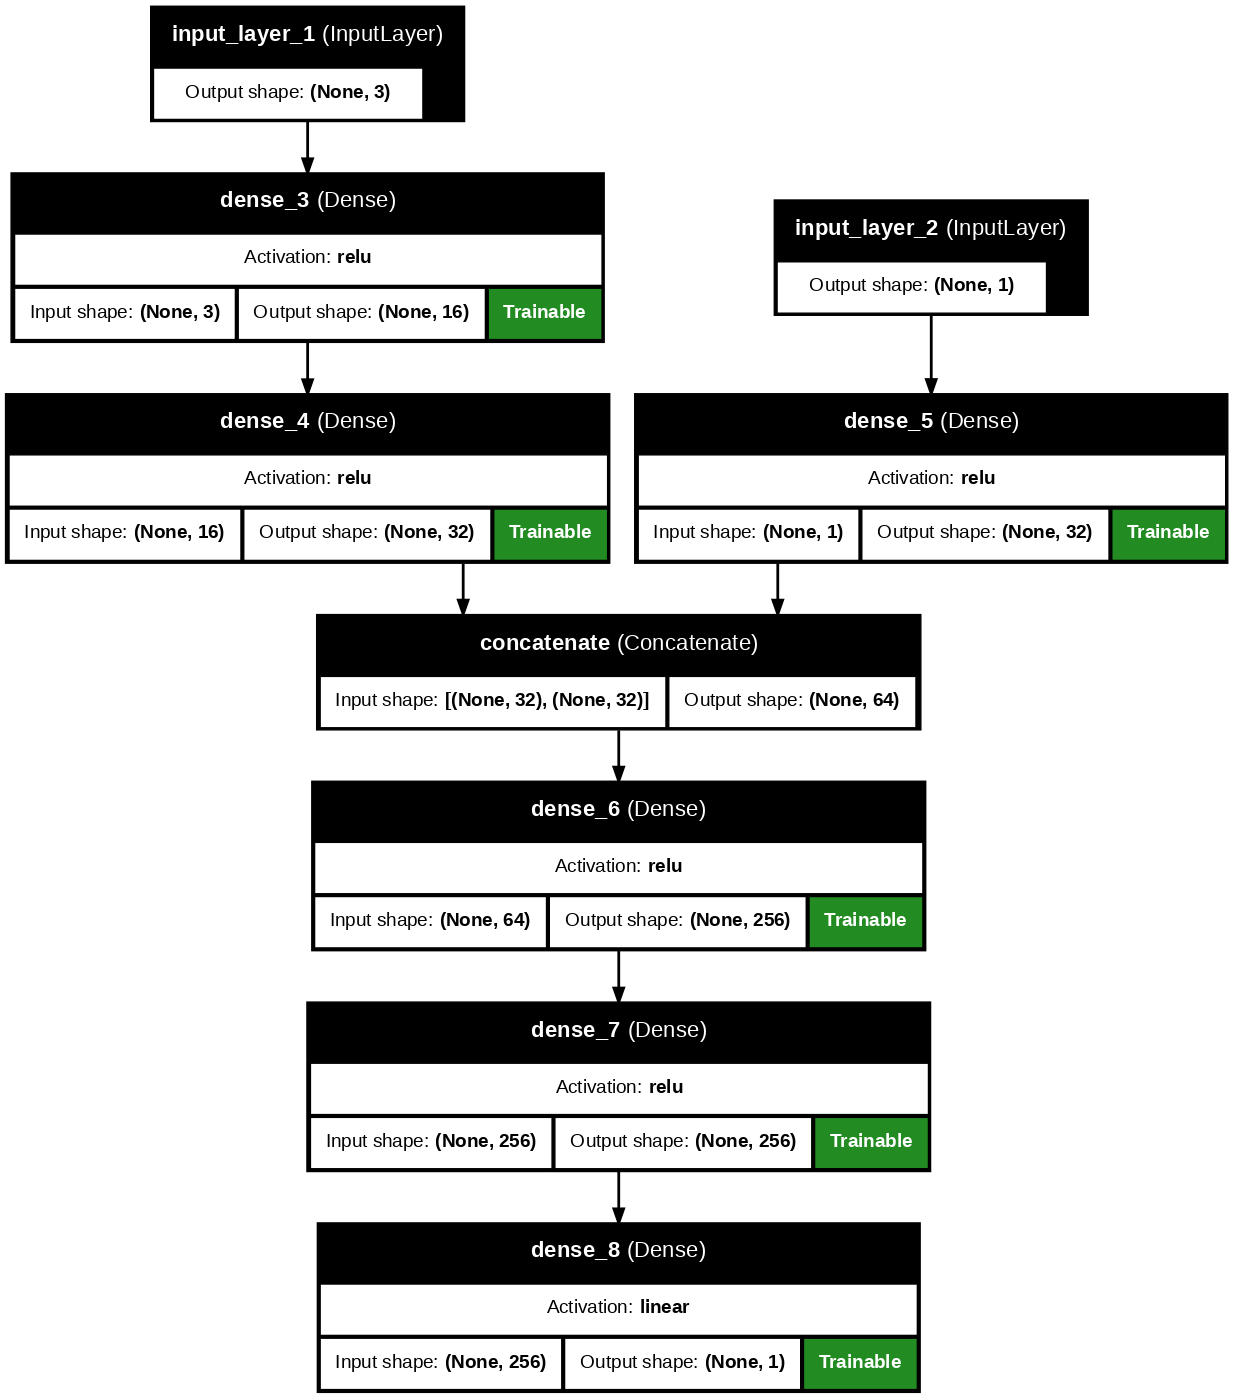

In [ ]:
keras.utils.plot_model(critic_model,show_shapes=True,show_layer_names=True, show_layer_activations=True,expand_nested=False, dpi=100, show_trainable=True)

In [ ]:
#######################################################tests
prev_state = env.reset()
print(prev_state)
print(type(prev_state))

[ 0.86312848 -0.50498438 -0.36680112]
<class 'numpy.ndarray'>


In [ ]:
tf_prev_state = tf.expand_dims(tf.convert_to_tensor(prev_state), 0)
print(tf_prev_state)
print(type(tf_prev_state))

tf.Tensor([[ 0.86312848 -0.50498438 -0.36680112]], shape=(1, 3), dtype=float64)
<class 'tensorflow.python.framework.ops.EagerTensor'>


In [ ]:
action = policy(tf_prev_state, ou_noise)
print(action)
print(type(action))

[array(-0.01132362)]
<class 'list'>


In [ ]:
state, reward, done, info , u , u_after_pid = env.step(action)

In [ ]:
print(state)
print(type(state))

[ 0.84440097 -0.53571168 -0.71972956]
<class 'numpy.ndarray'>


In [ ]:
print(reward)
print(type(reward))

-0.29371001162095167
<class 'numpy.float64'>


In [ ]:
print(done)
print(type(done))

False
<class 'bool'>


In [ ]:
# To store reward history of each episode
ep_reward_list = []
# To store average reward history of last few episodes
avg_reward_list = []

# Takes about 4 min to train
for ep in range(total_episodes):

    prev_state = env.reset()
    episodic_reward = 0

    while True:
        # Uncomment this to see the Actor in action
        # But not in a python notebook.
        # env.render()

        tf_prev_state = tf.expand_dims(tf.convert_to_tensor(prev_state), 0)

        action = policy(tf_prev_state, ou_noise)

        # Recieve state and reward from environment.
        state, reward, done, info , u , u_after_pid = env.step(action)

        buffer.record((prev_state, action, reward, state))
        episodic_reward += reward

        buffer.learn()
        #update_target(target_actor.variables, actor_model.variables, tau)
        #update_target(target_critic.variables, critic_model.variables, tau)
        update_target(target_actor, actor_model, tau)
        update_target(target_critic, critic_model, tau)

        # End this episode when `done` is True
        if done:
            break

        prev_state = state

    ep_reward_list.append(episodic_reward)

    # Mean of last 40 episodes
    avg_reward = np.mean(ep_reward_list[-40:])
    print("Episode * {} * Acc Reward is ==> {}".format(ep, f"{avg_reward:.3f}"))
    avg_reward_list.append(avg_reward)



Episode * 0 * Acc Reward is ==> -1049.077
Episode * 1 * Acc Reward is ==> -1201.204
Episode * 2 * Acc Reward is ==> -1391.019
Episode * 3 * Acc Reward is ==> -1460.260
Episode * 4 * Acc Reward is ==> -1456.344
Episode * 5 * Acc Reward is ==> -1468.443
Episode * 6 * Acc Reward is ==> -1474.887
Episode * 7 * Acc Reward is ==> -1466.282
Episode * 8 * Acc Reward is ==> -1445.429
Episode * 9 * Acc Reward is ==> -1450.063
Episode * 10 * Acc Reward is ==> -1411.396
Episode * 11 * Acc Reward is ==> -1376.409
Episode * 12 * Acc Reward is ==> -1343.986
Episode * 13 * Acc Reward is ==> -1276.246
Episode * 14 * Acc Reward is ==> -1245.141
Episode * 15 * Acc Reward is ==> -1226.432
Episode * 16 * Acc Reward is ==> -1200.775
Episode * 17 * Acc Reward is ==> -1160.928
Episode * 18 * Acc Reward is ==> -1106.492
Episode * 19 * Acc Reward is ==> -1051.343
Episode * 20 * Acc Reward is ==> -1007.216
Episode * 21 * Acc Reward is ==> -967.272
Episode * 22 * Acc Reward is ==> -930.675
Episode * 23 * Acc Rewa

In [ ]:
### Test

In [ ]:
total_episodes_test = 100
ep_reward_list_test = []
#avg_reward_list_test = []
best_score = -1600

In [ ]:
# Takes about 4 min to train
print('Test')
for ep in range(total_episodes_test):
    prev_state = env.reset()
    save_observation_temp = [prev_state]
    save_u1_temp = [0.0]
    save_pid_u1_temp = [0.0]
    save_ctrl_voltage_temp = []
    episodic_reward = 0

    while True:
        # Uncomment this to see the Actor in action
        # But not in a python notebook.
        # env.render()

        tf_prev_state = tf.expand_dims(tf.convert_to_tensor(prev_state), 0)

        action = policy(tf_prev_state, ou_noise)

        # Recieve state and reward from environment.
        state, reward, done, info , u , u_after_pid = env.step(action)
        save_observation_temp.append(state)
        save_u1_temp.append(u)
        save_pid_u1_temp.append(u_after_pid)
        save_ctrl_voltage_temp.append(env.DCMotorModel.voltage_input)

        episodic_reward += reward

        # End this episode when `done` is True
        if done:
            break

        prev_state = state
    save_ctrl_voltage_temp.append(env.DCMotorModel.voltage_input)
    ep_reward_list_test.append(episodic_reward)

    # Mean of last 10 episodes
    avg_reward = np.mean(ep_reward_list_test[-10:])
    print("Episode * {} * Acc Reward is ==> {} (last 10 ep AVG: {})".format(ep, f"{episodic_reward:.3f}" ,f"{avg_reward:.3f}"))
    if best_score<episodic_reward:
      save_observation = list(save_observation_temp)
      save_u1 = list(save_u1_temp)
      save_pid_u1 = list(save_pid_u1_temp)
      save_ctrl_voltage = list(save_ctrl_voltage_temp)
      best_score = episodic_reward
    #avg_reward_list_test.append(avg_reward)

Test
Episode * 0 * Acc Reward is ==> -134.689 (last 10 ep AVG: -134.689)
Episode * 1 * Acc Reward is ==> -3.465 (last 10 ep AVG: -69.077)
Episode * 2 * Acc Reward is ==> -120.612 (last 10 ep AVG: -86.255)
Episode * 3 * Acc Reward is ==> -131.661 (last 10 ep AVG: -97.607)
Episode * 4 * Acc Reward is ==> -133.688 (last 10 ep AVG: -104.823)
Episode * 5 * Acc Reward is ==> -119.216 (last 10 ep AVG: -107.222)
Episode * 6 * Acc Reward is ==> -242.404 (last 10 ep AVG: -126.533)
Episode * 7 * Acc Reward is ==> -232.355 (last 10 ep AVG: -139.761)
Episode * 8 * Acc Reward is ==> -232.191 (last 10 ep AVG: -150.031)
Episode * 9 * Acc Reward is ==> -124.699 (last 10 ep AVG: -147.498)
Episode * 10 * Acc Reward is ==> -368.064 (last 10 ep AVG: -170.835)
Episode * 11 * Acc Reward is ==> -132.626 (last 10 ep AVG: -183.752)
Episode * 12 * Acc Reward is ==> -127.010 (last 10 ep AVG: -184.391)
Episode * 13 * Acc Reward is ==> -135.011 (last 10 ep AVG: -184.726)
Episode * 14 * Acc Reward is ==> -225.717 (l

In [ ]:
save_observation_temp = None
save_u1_temp = None
save_pid_u1_temp = None
save_ctrl_voltage_temp = None

In [ ]:
# Create a dictionary of variables you want to save
variables_to_save = {
    'ep_reward_list': ep_reward_list,
    'avg_reward_list': avg_reward_list,
    'save_observation': save_observation,
    'save_u1': save_u1,
    'save_pid_u1': save_pid_u1,
    'save_ctrl_voltage': save_ctrl_voltage,
    'ep_reward_list_test':ep_reward_list_test
}

In [ ]:
path = '/content/drive/MyDrive/Colab Notebooks/codes/Fixed PID Constants/save_data/Pendulum/'

In [ ]:
# Save the weights
actor_model.save_weights(path+"pendulum_actor.weights.h5")
critic_model.save_weights(path+"pendulum_critic.weights.h5")

target_actor.save_weights(path+"pendulum_target_actor.weights.h5")
target_critic.save_weights(path+"pendulum_target_critic.weights.h5")

In [ ]:
#save_path = '/content/drive/MyDrive/Colab Notebooks/codes/Fixed PID Constants/save_data/Cartpole/Pendulum.pkl'
with open(path+'Pendulum.pkl', 'wb') as f:
    pickle.dump(variables_to_save, f)
print(f"All variables saved to {path+'Pendulum.pkl'}")

All variables saved to /content/drive/MyDrive/Colab Notebooks/codes/Fixed PID Constants/save_data/Pendulum/Pendulum.pkl


In [ ]:
# Define the file path
path = '/content/drive/MyDrive/Colab Notebooks/codes/Fixed PID Constants/save_data/Pendulum/'

In [ ]:
actor_model = get_actor()
critic_model = get_critic()
target_actor = get_actor()
target_critic = get_critic()

In [ ]:
actor_model.load_weights(path+"pendulum_actor.weights.h5")
critic_model.load_weights(path+"pendulum_critic.weights.h5")
target_actor.load_weights(path+"pendulum_target_actor.weights.h5")
target_critic.load_weights(path+"pendulum_target_critic.weights.h5")

In [ ]:
# Define the file path
path = '/content/drive/MyDrive/Colab Notebooks/codes/Fixed PID Constants/save_data/Pendulum/'
# Open the file in read-binary mode and load the dictionary
with open(path+'Pendulum.pkl', 'rb') as f:
    loaded_variables = pickle.load(f)

# Access the loaded variables
ep_reward_list = loaded_variables['ep_reward_list']
avg_reward_list = loaded_variables['avg_reward_list']
save_observation = loaded_variables['save_observation']
save_u1 = loaded_variables['save_u1']
save_pid_u1 = loaded_variables['save_pid_u1']
save_ctrl_voltage = loaded_variables['save_ctrl_voltage']
ep_reward_list_test=loaded_variables['ep_reward_list_test']

In [ ]:
plt.rc('text.latex', preamble=r'\usepackage{amsmath,amssymb,amsfonts}')
#plt.rcParams["text.usetex"]=False
#plt.rcParams["font.family"] = "sans-serif"
#plt.rcParams["font.family"] = "serif"
#plt.rcParams['mathtext.fontset'] = 'cm'
#plt.rcParams['mathtext.fontset'] = 'dejavusans'
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'STIXGeneral'

In [ ]:
def unnorm_to_norm(x):
  y = (x-low_bound_reward_list)/(up_bound_reward_list-low_bound_reward_list)
  return y

In [ ]:
def norm_to_unnorm(y):
  x=y*(up_bound_reward_list-low_bound_reward_list)+low_bound_reward_list
  return x

In [ ]:
norm_reward_list = np.array(avg_reward_list)
low_bound_reward_list = -3254.72 #=-(pi**2 + 0.1 * 8**2 + 0.001 * 2**2)*(200 time step) #norm_reward_list.min()
up_bound_reward_list=0
print("low_bound_reward_list=",low_bound_reward_list)
print("up_bound_reward_list=",up_bound_reward_list)
#norm_reward_list = (norm_reward_list-min_norm_reward_list)/(max_norm_reward_list-min_norm_reward_list)
norm_reward_list = unnorm_to_norm(norm_reward_list)

low_bound_reward_list= -3254.72
up_bound_reward_list= 0


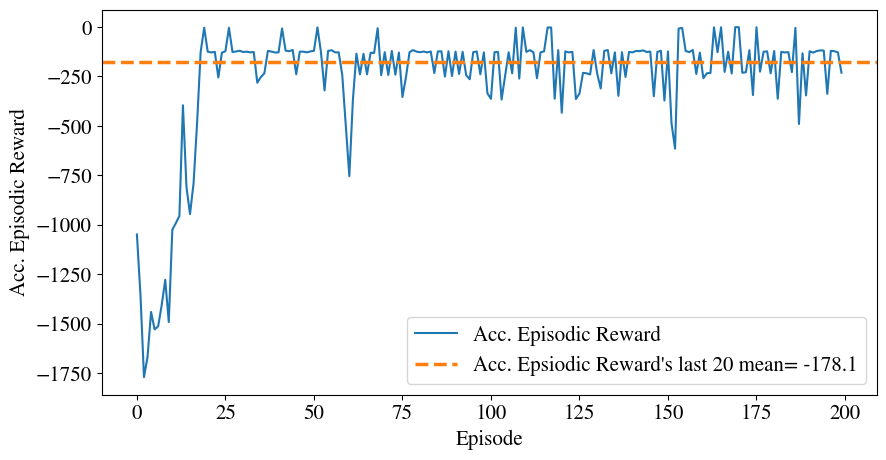

In [ ]:
# Plotting graph
# Episodes versus Acc. Rewards
font = {'size': 15}
plt.rc('font', **font)
f = plt.figure()
f.set_figwidth(10)
f.set_figheight(5)
#plt.rc('text.latex', preamble=r'\usepackage{amsmath}')
plt.plot(ep_reward_list, label = "Acc. Episodic Reward",color="C0",linewidth = 1.5)
plt.axhline(y=np.array(ep_reward_list)[-20:-1].mean(), linestyle='--',
            label = "Acc. Epsiodic Reward's last 20 mean= "+f"{np.array(ep_reward_list)[-20:-1].mean():.1f}",color="C1",linewidth = 2.5)
plt.xlabel("Episode")
plt.ylabel("Acc. Episodic Reward")
#plt.grid()
plt.legend()
plt.show()

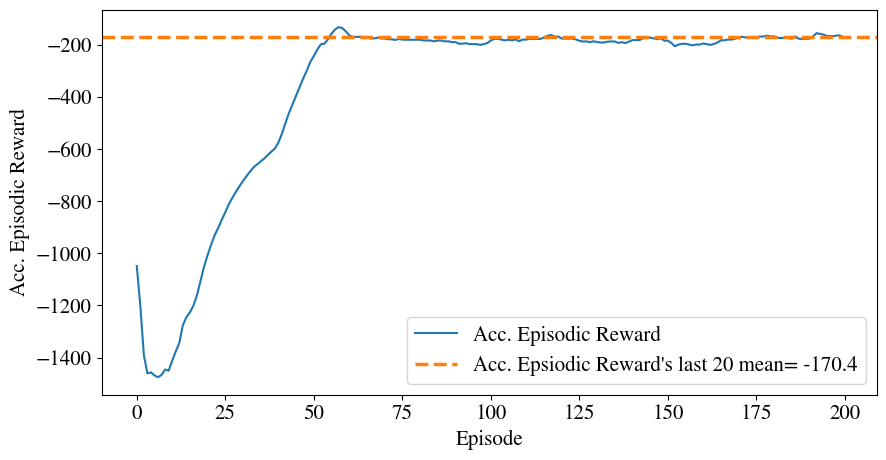

In [ ]:
# Plotting graph
# Episodes versus Acc. Rewards
font = {'size': 15}
plt.rc('font', **font)
f = plt.figure()
f.set_figwidth(10)
f.set_figheight(5)
#plt.rc('text.latex', preamble=r'\usepackage{amsmath}')
plt.plot(avg_reward_list, label = "Acc. Episodic Reward",color="C0",linewidth = 1.5)
plt.axhline(y=np.array(avg_reward_list)[-20:-1].mean(), linestyle='--',
            label = "Acc. Epsiodic Reward's last 20 mean= "+f"{np.array(avg_reward_list)[-20:-1].mean():.1f}",color="C1",linewidth = 2.5)
plt.xlabel("Episode")
plt.ylabel("Acc. Episodic Reward")
#plt.grid()
plt.legend()
plt.show()

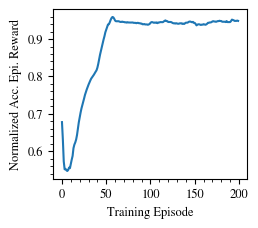

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# Episodes versus Norm Acc. Ep. Rewards

font = {'size': 9}
plt.rc('font', **font)
f = plt.figure()
f.set_figwidth(2.5)
f.set_figheight(2.2)
plt.plot(norm_reward_list, label = "Normalized Acc. Epi. Reward",color="C0",linewidth = 1.5)
#plt.axhline(y=norm_reward_list[-20:-1].mean(), linestyle='--',
#            label = "Normalized Acc. Episodic Reward's last 20 mean= "+f"{norm_reward_list[-20:-1].mean():.1f}",color="C1",linewidth = 2.5)
plt.xlabel("Training Episode")
plt.ylabel("Normalized Acc. Epi. Reward")
#plt.grid()
#plt.legend()
plt.minorticks_on()
plt.xticks(np.arange(0, len(norm_reward_list)+1, 50))
#plt.yticks(np.arange(0.0, 1.0, 0.1))
plt.savefig(path+"Pendulum_Acc_Reward_vs_Episode.pdf", format='pdf', bbox_inches='tight')
plt.show()

/usr/local/lib/python3.12/dist-packages/matplotlib/_fontconfig_pattern.py:85: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  parse = parser.parseString(pattern)
/usr/local/lib/python3.12/dist-packages/matplotlib/_fontconfig_pattern.py:89: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  parser.resetCache()
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2010: PyparsingDeprecationWarning: 'oneOf' deprecated - use 'one_of'
  p.space          = oneOf(self._space_widths)("space")
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2020: PyparsingDeprecationWarning: 'leaveWhitespace' deprecated - use 'leave_whitespace'
  )("sym").leaveWhitespace()
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:1984: PyparsingDeprecationWarning: 'setName' deprecated - use 'set_name'
  val.setName(key)
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:1987: PyparsingDeprecationWarning: 'setParseA

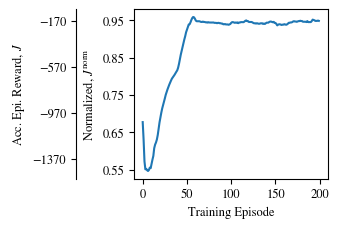

In [ ]:
# Episodes versus Acc. Ep. Rewards (Norm and Unnorm)

font = {'size': 9}
plt.rc('font', **font)
f = plt.figure()
f.set_figwidth(2.5)
f.set_figheight(2.2)
plt.plot(norm_reward_list,color="C0",linewidth = 1.5)
plt.xlabel("Training Episode")
plt.ylabel(r"Normalized, $J^\text{norm}$")
plt.xticks(np.arange(0, len(norm_reward_list)+1, 50))
plt.yticks(np.arange(0.55, 0.96, 0.1))
ax = plt.gca()
secax_y = ax.secondary_yaxis(
    -0.3, functions=(norm_to_unnorm, unnorm_to_norm))
secax_y.set_ylabel(r"Acc. Epi. Reward, $J$")
secax_y.set_yticks(np.arange(-170, -2000, -400))
#plt.savefig(path+"Pendulum_Acc_Reward_vs_Episode.pdf", format='pdf', bbox_inches='tight')
plt.show()

In [ ]:
print("Acc. Epsiodic Reward's last 20 mean=")
print(np.array
      (avg_reward_list[-20:-1]).mean())

Acc. Epsiodic Reward's last 20 mean=
-170.4300265580128


In [ ]:
print("Normalized Acc. Epsiodic Reward's last 20 mean=")
print(norm_reward_list[-20:-1].mean())

Normalized Acc. Epsiodic Reward's last 20 mean=
0.9476360404096166


In [ ]:
# Test Histogram
norm_ep_reward_list_test = np.array(ep_reward_list_test)
norm_ep_reward_list_test = unnorm_to_norm(norm_ep_reward_list_test)

In [ ]:
print(norm_ep_reward_list_test.max())
print(norm_ep_reward_list_test.min())
min_bin = int(norm_ep_reward_list_test.min()*10)/10
print(min_bin)

0.9992561434883945
0.8630558134833607
0.8


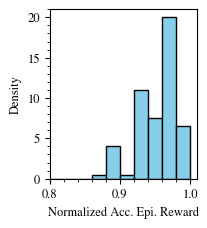

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
font = {'size': 9}
plt.rc('font', **font)
f = plt.figure()
f.set_figwidth(1.9)
f.set_figheight(2.2)
data_rewards = np.array(norm_ep_reward_list_test)
density_True = True
#bins_norm = unnorm_to_norm(np.arange(-680,0,85))
plt.hist(data_rewards, bins=np.arange(0,1.01,0.02), density=density_True ,color='skyblue', edgecolor='black')
plt.xlabel('Normalized Acc. Epi. Reward')
ylabel='Density'if density_True else 'Frequency'
plt.ylabel(ylabel)
#plt.xticks(np.arange(0.8,1.01,0.05))
plt.minorticks_on()
plt.xlim((0.80,1.01))
plt.savefig(path+"Pendulum_Acc_Reward_vs_Episode_Test_Hist.pdf", format='pdf', bbox_inches='tight')
plt.show()

In [ ]:
print("Test Normalized Acc Episodic Reward's Results:")
print(f"Unnormalized: max={norm_to_unnorm(data_rewards).max():.3f} ,mean={norm_to_unnorm(data_rewards).mean():.3f}, std={norm_to_unnorm(data_rewards).std():.3f}")
print(f"Normalized:   max={data_rewards.max():.3e} ,mean={data_rewards.mean():.3e}, std={data_rewards.std():.3e}")

Test Normalized Acc Episodic Reward's Results:
Unnormalized: max=-2.421 ,mean=-158.261, std=96.776
Normalized:   max=9.993e-01 ,mean=9.514e-01, std=2.973e-02


In [ ]:
#!pip install latex

In [ ]:
dt = env.dt
#dt=0.05

/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2170: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  result = self._expression.parseString(s)
/usr/local/lib/python3.12/dist-packages/pyparsing/util.py:466: PyparsingDeprecationWarning: 'parseAll' argument is deprecated, use 'parse_all'
  return fn(self, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2178: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  ParserElement.resetCache()
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2170: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_stri

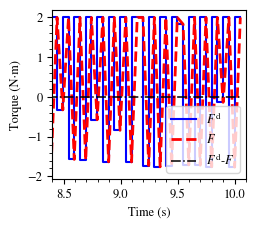

In [ ]:
time_position_u1= np.linspace(start = 0, stop = len(save_u1)* dt,num=len(save_u1) )
time_position__pid_u1= np.linspace(start = 0, stop = len(save_u1)* dt,num=len(save_u1) )

e_ry=np.array(save_u1)-np.array(save_pid_u1)

mean_std=f'(mean,std)=({e_ry.mean():.3e}, {e_ry.std():.3e})'
font = {'size': 9}
plt.rc('font', **font)
f = plt.figure()
f.set_figwidth(2.5)
f.set_figheight(2.2)

plt.step(time_position_u1, save_u1 ,label = r"$F^\mathrm{d}$",color="blue",linewidth = 1.5)
plt.plot(time_position__pid_u1, save_pid_u1, '--',label = r"$F$",color="red",linewidth = 2) #':' or '--'
plt.plot(time_position_u1, e_ry,'-.',label = r"$F^\mathrm{d}$-$F$",color="black",linewidth = 1.1)

plt.minorticks_on()

plt.xlabel("Time (s)")
plt.ylabel("Torque (N⋅m)")
plt.legend(fontsize=9)#(bbox_to_anchor=(1, 1), loc='upper left')
#plt.grid()
plt.xlim((8.4,10.1))
plt.savefig(path+"Pendulum_Torque_vs_Time.pdf", format='pdf', bbox_inches='tight')
plt.show()

In [ ]:
print(mean_std)

(mean,std)=(8.987e-05, 7.301e-04)


In [ ]:
print(f"mae={np.abs(e_ry).mean():.3e}")

mae=8.987e-05


In [ ]:
import matplotlib.patheffects as pe

/usr/local/lib/python3.12/dist-packages/matplotlib/_fontconfig_pattern.py:85: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  parse = parser.parseString(pattern)
/usr/local/lib/python3.12/dist-packages/matplotlib/_fontconfig_pattern.py:89: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  parser.resetCache()
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2010: PyparsingDeprecationWarning: 'oneOf' deprecated - use 'one_of'
  p.space          = oneOf(self._space_widths)("space")
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2020: PyparsingDeprecationWarning: 'leaveWhitespace' deprecated - use 'leave_whitespace'
  )("sym").leaveWhitespace()
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:1984: PyparsingDeprecationWarning: 'setName' deprecated - use 'set_name'
  val.setName(key)
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:1987: PyparsingDeprecationWarning: 'setParseA

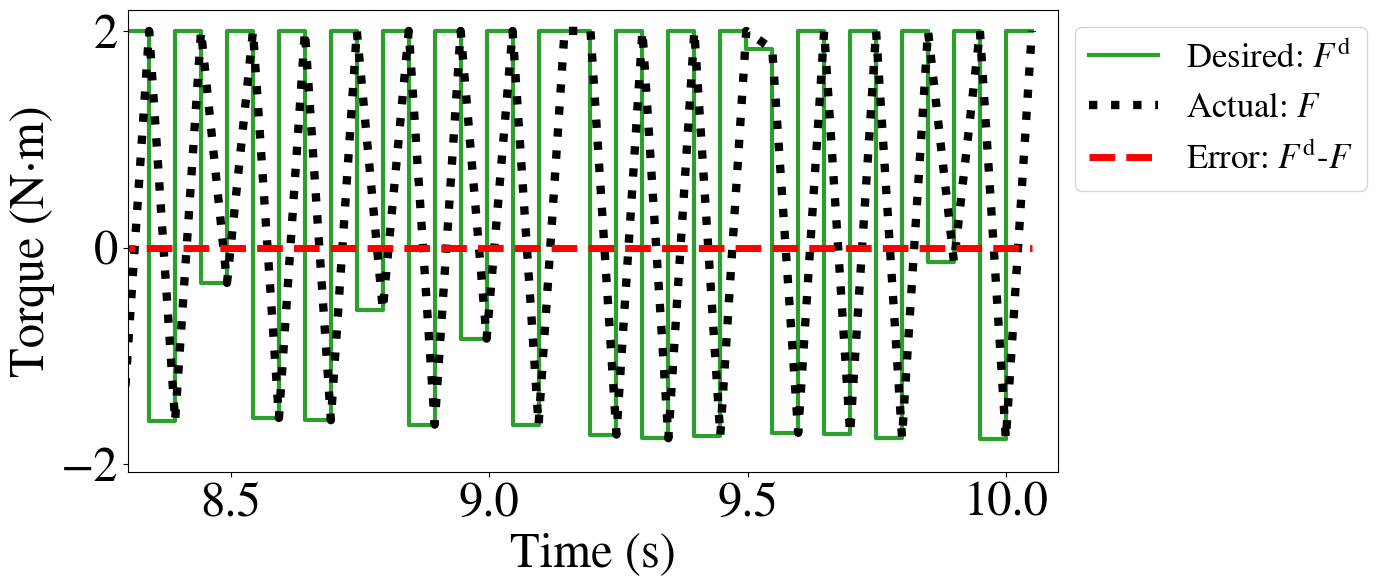

In [ ]:
time_position_u1= np.linspace(start = 0, stop = len(save_u1)* dt,num=len(save_u1) )
time_position__pid_u1= np.linspace(start = 0, stop = len(save_u1)* dt,num=len(save_u1) )

e_ry=np.array(save_u1)-np.array(save_pid_u1)

mean_std=f'(mean,std)=({e_ry.mean():.1e}, {e_ry.std():.1e})'
font = {'size': 35}
plt.rc('font', **font)
f = plt.figure()
f.set_figwidth(12)
f.set_figheight(6)

plt.step(time_position_u1, save_u1 ,label = r"Desired: $F^\mathrm{d}$",color="tab:green",linewidth = 3)
plt.plot(time_position__pid_u1, save_pid_u1, ':',label = r"Actual: $F$",color='k',linewidth = 6) #':' or '--'
plt.plot(time_position_u1, e_ry,'--',label = r"Error: $F^\mathrm{d}$-$F$",color="red",linewidth = 5)

#plt.minorticks_on()

plt.xlabel("Time (s)")
plt.ylabel("Torque (N⋅m)")
plt.legend(fontsize=25,bbox_to_anchor=(1, 1), loc='upper left')
#plt.grid()
plt.xlim((8.3,10.1))
plt.savefig(path+"Pendulum_Torque_vs_Time_toPoster.png", bbox_inches='tight')
plt.show()

In [ ]:
print(f'F^2 mean={(np.array(save_u1)**2).mean():.2f}')

F^2 mean=3.30


In [ ]:
print(mean_std)

(mean,std)=(9.0e-05, 7.3e-04)


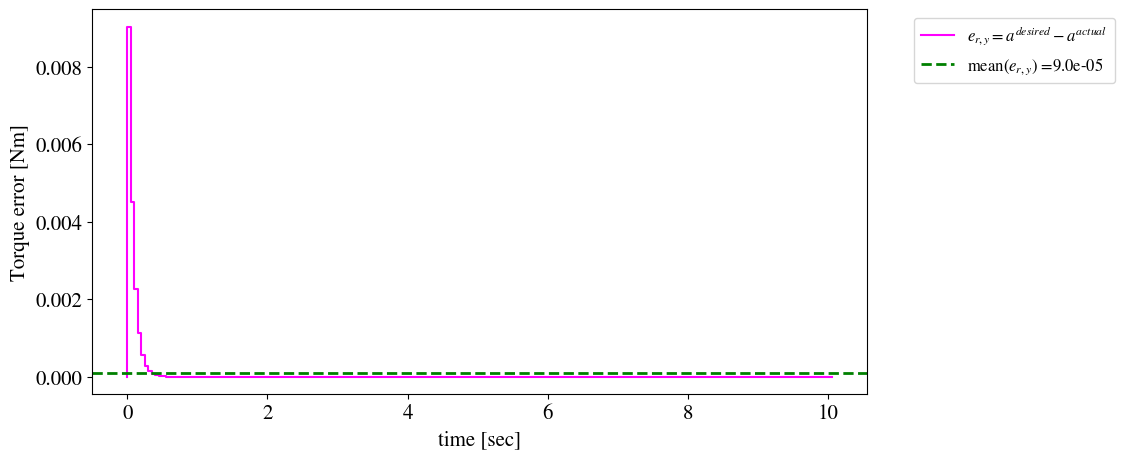

In [ ]:
font = {'size': 15}
plt.rc('font', **font)
f = plt.figure()
f.set_figwidth(10)
f.set_figheight(5)
#plt.rc('text.latex', preamble=r'\usepackage{amsmath}')

e_ry=np.array(save_u1)-np.array(save_pid_u1)


plt.step(time_position_u1, e_ry ,label = "$e_{r,y}=a^{desired}-a^{actual}$ ",color="magenta",linewidth = 1.5)
plt.axhline(y=e_ry.mean(), color="green",linewidth = 2, linestyle='--', label='mean($e_{r,y}$) =' +f'{e_ry.mean():.1e}')


plt.xlabel("time [sec]")
plt.ylabel("Torque error [Nm]")
plt.legend(fontsize=12, bbox_to_anchor=(1.05, 1.0), loc='upper left')
#plt.grid()
plt.show()

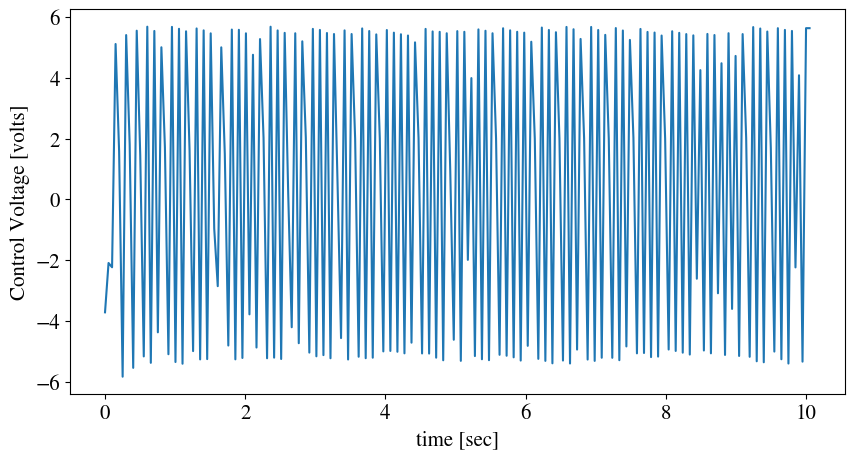

In [ ]:
font = {'size': 15}
plt.rc('font', **font)
f = plt.figure()
f.set_figwidth(10)
f.set_figheight(5)

plt.plot(time_position_u1, save_ctrl_voltage)
plt.xlabel("time [sec]")
plt.ylabel("Control Voltage [volts]")
#plt.grid()
plt.show()

In [ ]:
import math

x_print = []
y_print = []
thetadot_print = []

for observ in save_observation:
  for index,value in enumerate(observ):
    if index == 0:
      x_print.append(value)
      #theta_print.append(math.acos(value))
    if index == 1:
      y_print.append(value)
    if index == 2:
      thetadot_print.append(value)

theta_print = list(np.arctan2(np.array(y_print), np.array(x_print)))

In [ ]:
print(len(x_print))

201


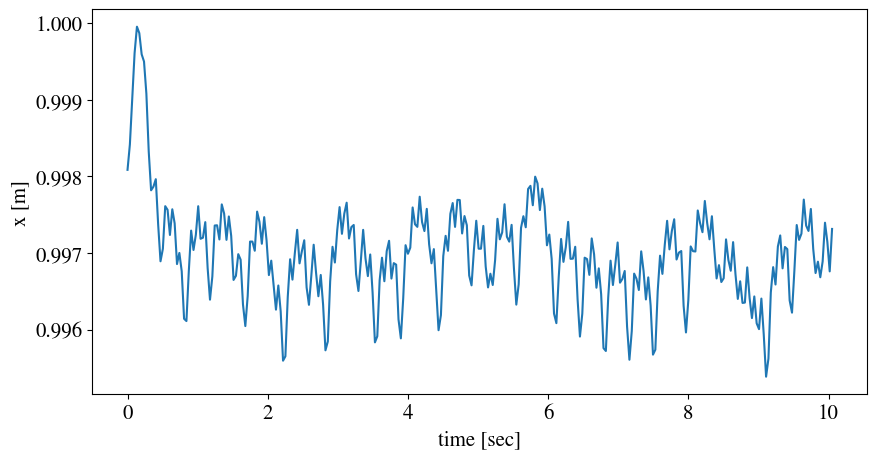

In [ ]:
from scipy.interpolate import make_interp_spline, BSpline

time_x_print = np.linspace(start = 0, stop = len(x_print)* dt,num=len(x_print))
# 300 represents number of points to make between T.min and T.max
xnew = np.linspace(0, time_x_print[-1] , 300)

spl = make_interp_spline(time_x_print, x_print, k=3)  # type: BSpline
power_smooth = spl(xnew)

font = {'size': 15}
plt.rc('font', **font)
f = plt.figure()
f.set_figwidth(10)
f.set_figheight(5)

plt.plot(xnew, power_smooth)
plt.xlabel("time [sec]")
plt.ylabel("x [m]")
#plt.grid()
plt.show()

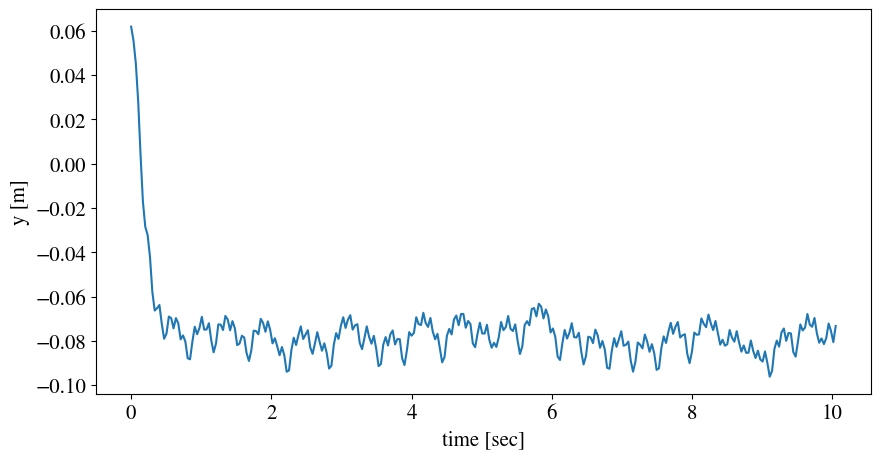

In [ ]:
from scipy.interpolate import make_interp_spline, BSpline

time_y_print = np.linspace(start = 0, stop = len(y_print)* dt,num=len(y_print))
# 300 represents number of points to make between T.min and T.max
xnew = np.linspace(0, time_y_print[-1] , 300)

spl = make_interp_spline(time_y_print, y_print, k=3)  # type: BSpline
power_smooth = spl(xnew)

font = {'size': 15}
plt.rc('font', **font)
f = plt.figure()
f.set_figwidth(10)
f.set_figheight(5)

plt.plot(xnew, power_smooth)
plt.xlabel("time [sec]")
plt.ylabel("y [m]")
#plt.grid()
plt.show()

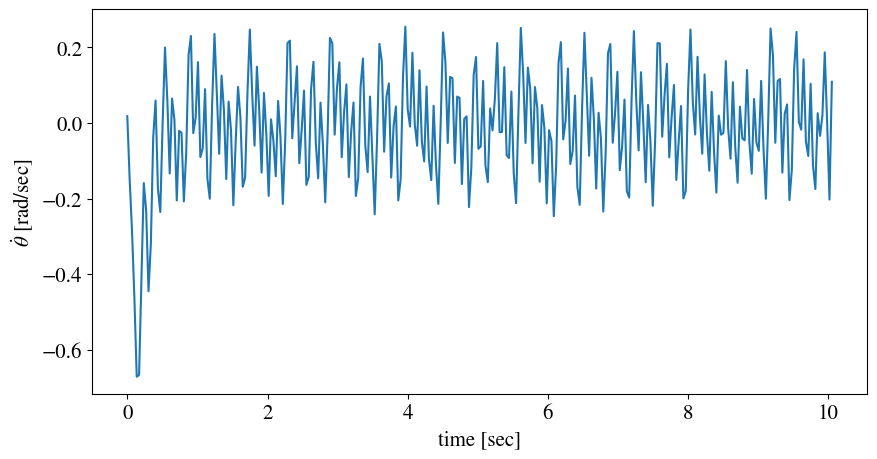

In [ ]:
from scipy.interpolate import make_interp_spline, BSpline

time_thetadot_print = np.linspace(start = 0, stop = len(thetadot_print)* dt,num=len(thetadot_print))
# 300 represents number of points to make between T.min and T.max
xnew = np.linspace(0, time_thetadot_print[-1] , 300)

spl = make_interp_spline(time_thetadot_print, thetadot_print, k=3)  # type: BSpline
power_smooth = spl(xnew)

font = {'size': 15}
plt.rc('font', **font)
f = plt.figure()
f.set_figwidth(10)
f.set_figheight(5)

plt.plot(xnew, power_smooth)
plt.xlabel("time [sec]")
#plt.rc('text.latex', preamble=r'\usepackage{amsmath}')
plt.ylabel(r'$\dot{\theta}$ [rad/sec]')
#plt.grid()
plt.show()

In [ ]:
time_theta_print = np.linspace(start = 0, stop = len(theta_print)* dt,num=len(theta_print))
# 300 represents number of points to make between T.min and T.max
xnew = np.linspace(0, time_theta_print[-1] , 300)

spl = make_interp_spline(time_theta_print, theta_print, k=3)  # type: BSpline
power_smooth_theta = spl(xnew)

/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2170: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  result = self._expression.parseString(s)
/usr/local/lib/python3.12/dist-packages/pyparsing/util.py:466: PyparsingDeprecationWarning: 'parseAll' argument is deprecated, use 'parse_all'
  return fn(self, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2178: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  ParserElement.resetCache()


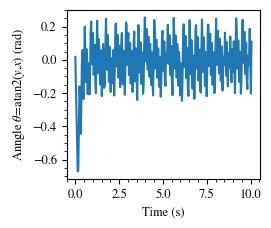

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
font = {'size': 9}
plt.rc('font', **font)
f = plt.figure()
f.set_figwidth(2.5)
f.set_figheight(2.2)

plt.plot(xnew, power_smooth)
plt.minorticks_on()
plt.xlabel("Time (s)")
#plt.rc('text.latex', preamble=r'\usepackage{amsmath}')
plt.ylabel(r'Anngle $\theta$=atan2($y$,$x$) (rad)')
#plt.grid()
plt.savefig(path+"Pendulum_Angle_vs_Time.pdf", format='pdf', bbox_inches='tight')
plt.show()

In [ ]:
from scipy.interpolate import make_interp_spline, BSpline

time_thetadot_print = np.linspace(start = 0, stop = len(thetadot_print)* dt,num=len(thetadot_print))
# 300 represents number of points to make between T.min and T.max
xnew = np.linspace(0, time_thetadot_print[-1] , 300)

spl = make_interp_spline(time_thetadot_print, thetadot_print, k=3)  # type: BSpline
power_smooth_theta_dot = spl(xnew)

In [ ]:
np.pi

3.141592653589793

/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2170: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  result = self._expression.parseString(s)
/usr/local/lib/python3.12/dist-packages/pyparsing/util.py:466: PyparsingDeprecationWarning: 'parseAll' argument is deprecated, use 'parse_all'
  return fn(self, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2178: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  ParserElement.resetCache()


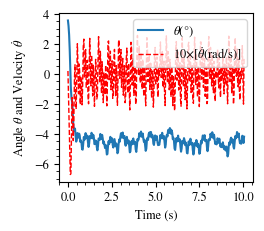

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
font = {'size': 9}
plt.rc('font', **font)
f = plt.figure()
f.set_figwidth(2.5)
f.set_figheight(2.2)

plt.plot(xnew, 180*power_smooth_theta/np.pi,label=r'$\theta(\degree)$',linewidth = 1.5)
plt.plot(xnew, 10*power_smooth_theta_dot,'--',color='red',label=r'10$\times$[$\dot{\theta}$(rad/s)]',linewidth = 1)
plt.minorticks_on()
plt.xlabel("Time (s)")
#plt.rc('text.latex', preamble=r'\usepackage{amsmath}')
#plt.ylabel(r'Angle $\theta$ (rad) and'+'\n'+r'Angular velocity $\dot{\theta}$ (rad/s)')
plt.ylabel(r'Angle $\theta$ and Velocity $\dot{\theta}$')
#plt.grid()
plt.legend()
plt.savefig(path+"Pendulum_Angle_and_Velocity_vs_Time.pdf", format='pdf', bbox_inches='tight')
plt.show()

In [ ]:
force_square_mean = (np.array(save_u1)**2).mean()
power_smooth_theta_mean = np.array(power_smooth_theta).mean()
power_smooth_square_theta_mean = np.array(power_smooth_theta**2).mean()
power_smooth_theta_dot_mean = np.array(power_smooth_theta_dot).mean()
power_smooth_square_theta_dot_mean = np.array(power_smooth_theta_dot**2).mean()

In [ ]:
reward_mean = -(power_smooth_square_theta_mean+0.1*power_smooth_square_theta_dot_mean+0.001*force_square_mean)

In [ ]:
print(f'F^2 mean={force_square_mean:.2f}')
print(f'theta mean={power_smooth_theta_mean:.2e} ({180*power_smooth_theta_mean/np.pi:.2f} degrees)')
print(f'theta_dot mean={power_smooth_theta_dot_mean:.2e}')
print(f'theta^2 mean={power_smooth_square_theta_mean:.2e}')
print(f'theta_dot^2 mean={power_smooth_square_theta_dot_mean:.2e}')


F^2 mean=3.30
theta mean=-7.58e-02 (-4.34 degrees)
theta_dot mean=-1.38e-02
theta^2 mean=6.04e-03
theta_dot^2 mean=2.12e-02


In [ ]:
print(f'reward_mean (in time) = {reward_mean:.2e}')
print(f'acc. episodic of mean reward={200*reward_mean:.3f}')

reward_mean (in time) = -1.15e-02
acc. episodic of mean reward=-2.292
